# Corporacion Favorita: EDA и первые baseline-модели

Цель ноутбука:
- быстро понять структуру данных и масштаб таблиц;
- выделить основные временные паттерны, промо-эффекты и внешние драйверы;
- зафиксировать риски для baseline-модели и проверить пару простых holdout-baseline.

Подход:
- небольшие таблицы читаем целиком;
- `train.csv` сканируем чанками и складываем агрегаты в `.cache/favorita/`, чтобы повторный запуск был быстрым.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.favorita_eda_utils import (
    build_daily_external_frame,
    build_test_coverage,
    build_train_eda_bundle,
    dataset_catalog,
    load_reference_tables,
)
from src.favorita_baselines import (
    build_baseline_validation_artifacts,
    predict_hierarchical_baseline,
    predict_recent_mean_baseline,
    summarize_baseline_results,
)
from src.favorita_models import run_lightgbm_validation_experiment
from src.favorita_models import (
    run_single_fold_time_series_experiment,
    run_time_series_cross_validation,
    train_final_time_series_model,
)
from src.favorita_catboost import (
    run_single_fold_catboost_experiment,
    run_catboost_optuna_search,
    train_final_catboost_model,
)
from src.configs import (
    DEFAULT_CATBOOST_POSTPROCESS_PARAMS,
    NOTEBOOK_CATBOOST_SINGLE_FOLD_PARAMS,
)
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path("data")

In [2]:
catalog = dataset_catalog(DATA_DIR)
tables = load_reference_tables(DATA_DIR)

stores = tables["stores"]
items = tables["items"]
transactions = tables["transactions"]
oil = tables["oil"]
holidays = tables["holidays"]
test = tables["test"]

reference_overview = pd.DataFrame(
    [
        {
            "table": "stores",
            "rows": len(stores),
            "cols": stores.shape[1],
            "date_min": pd.NaT,
            "date_max": pd.NaT,
            "missing_share": stores.isna().mean().mean(),
        },
        {
            "table": "items",
            "rows": len(items),
            "cols": items.shape[1],
            "date_min": pd.NaT,
            "date_max": pd.NaT,
            "missing_share": items.isna().mean().mean(),
        },
        {
            "table": "transactions",
            "rows": len(transactions),
            "cols": transactions.shape[1],
            "date_min": transactions["date"].min(),
            "date_max": transactions["date"].max(),
            "missing_share": transactions.isna().mean().mean(),
        },
        {
            "table": "oil",
            "rows": len(oil),
            "cols": oil.shape[1],
            "date_min": oil["date"].min(),
            "date_max": oil["date"].max(),
            "missing_share": oil.isna().mean().mean(),
        },
        {
            "table": "holidays_events",
            "rows": len(holidays),
            "cols": holidays.shape[1],
            "date_min": holidays["date"].min(),
            "date_max": holidays["date"].max(),
            "missing_share": holidays.isna().mean().mean(),
        },
        {
            "table": "test",
            "rows": len(test),
            "cols": test.shape[1],
            "date_min": test["date"].min(),
            "date_max": test["date"].max(),
            "missing_share": test.isna().mean().mean(),
        },
    ]
)

display(catalog)
display(reference_overview)

,file,size_mb,loading_strategy
0,train.csv,"4,765.940",chunked scan
1,test.csv,120.320,in-memory
2,sample_submission.csv,38.570,in-memory
3,transactions.csv,1.480,in-memory
4,items.csv,0.100,in-memory
5,holidays_events.csv,0.020,in-memory
6,oil.csv,0.020,in-memory
7,stores.csv,0.000,in-memory


,table,rows,cols,date_min,date_max,missing_share
0,stores,54,5,NaT,NaT,0.000
1,items,4100,4,NaT,NaT,0.000
2,transactions,83488,3,2013-01-01,2017-08-15,0.000
3,oil,1218,2,2013-01-01,2017-08-31,0.018
4,holidays_events,350,6,2012-03-02,2017-12-26,0.000
5,test,3370464,4,2017-08-16,2017-08-31,0.000


## Метаданные по магазинам и товарам

До чтения `train.csv` полезно понять, насколько неоднородны сами сущности:
- в `stores.csv` есть тип магазина, география и cluster;
- в `items.csv` есть family/class/perishable, что сразу даёт естественные агрегирующие признаки.

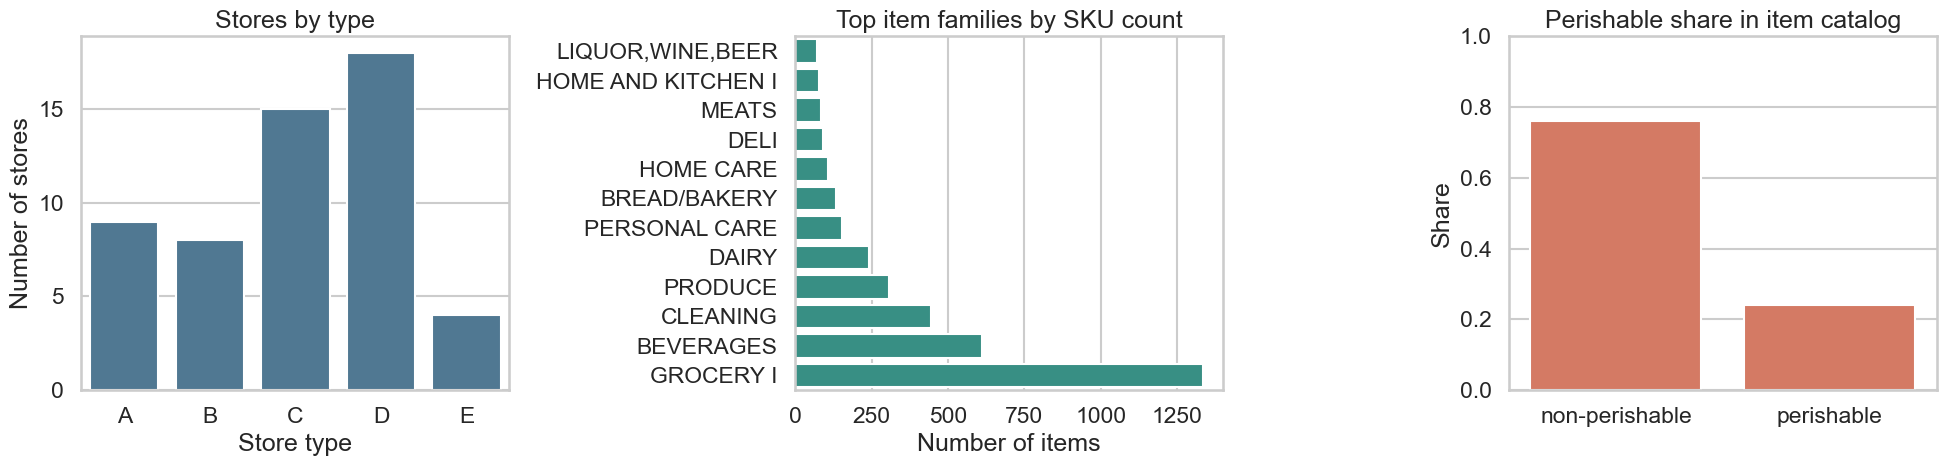

In [3]:
store_type_counts = stores["type"].value_counts().sort_index().rename_axis("type").reset_index(name="stores")
top_families_by_items = (
    items["family"].value_counts().head(12).sort_values().rename_axis("family").reset_index(name="item_count")
)
perishable_share = pd.DataFrame(
    {
        "bucket": ["non-perishable", "perishable"],
        "share": [1 - items["perishable"].mean(), items["perishable"].mean()],
    }
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=store_type_counts, x="type", y="stores", ax=axes[0], color="#457b9d")
axes[0].set_title("Stores by type")
axes[0].set_xlabel("Store type")
axes[0].set_ylabel("Number of stores")

sns.barplot(data=top_families_by_items, x="item_count", y="family", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Top item families by SKU count")
axes[1].set_xlabel("Number of items")
axes[1].set_ylabel("")

sns.barplot(data=perishable_share, x="bucket", y="share", ax=axes[2], color="#e76f51")
axes[2].set_title("Perishable share in item catalog")
axes[2].set_xlabel("")
axes[2].set_ylabel("Share")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Full-train summary через чанки

`train.csv` содержит более 125 млн строк, поэтому ниже используется один полный проход по данным:
- считаются глобальные статистики;
- собираются ежедневные агрегаты;
- отдельно агрегируются продажи по `family` и `store_nbr`;
- результаты кешируются, чтобы повторный запуск ноутбука не перечитывал весь файл заново.

In [4]:
train_eda = build_train_eda_bundle(DATA_DIR)

daily_sales = train_eda["daily_sales"].copy()
family_sales = train_eda["family_sales"].copy()
store_sales = train_eda["store_sales"].copy()
promotion_summary = train_eda["promotion_summary"].copy()
daily_frame = build_daily_external_frame(daily_sales, transactions, oil)

overview = train_eda["overview"]
train_summary = pd.DataFrame(
    [
        {"metric": "train_rows", "value": f"{overview['rows']:,}"},
        {"metric": "train_start", "value": str(overview["date_min"].date())},
        {"metric": "train_end", "value": str(overview["date_max"].date())},
        {"metric": "n_days", "value": f"{overview['n_days']:,}"},
        {"metric": "unique_stores", "value": f"{overview['unique_stores']:,}"},
        {"metric": "unique_items", "value": f"{overview['unique_items']:,}"},
        {"metric": "missing_onpromotion_rate", "value": f"{overview['missing_onpromotion_rate']:.2%}"},
        {"metric": "negative_sales_rate", "value": f"{overview['negative_sales_rate']:.4%}"},
        {"metric": "total_unit_sales", "value": f"{overview['total_unit_sales']:,.0f}"},
    ]
)

promotion_display = promotion_summary.copy()
promotion_display["records"] = promotion_display["records"].map(lambda value: f"{value:,}")
promotion_display["record_share_known"] = promotion_display["record_share_known"].map(lambda value: f"{value:.2%}")
promotion_display["unit_sales"] = promotion_display["unit_sales"].map(lambda value: f"{value:,.0f}")
promotion_display["avg_unit_sales_per_record"] = promotion_summary["avg_unit_sales_per_record"].round(3)

display(train_summary)
display(build_test_coverage(test, train_eda["train_items"], train_eda["train_stores"]))
display(promotion_display)

,metric,value
0,train_rows,"125,497,040"
1,train_start,2013-01-01
2,train_end,2017-08-15
3,n_days,"1,684"
4,unique_stores,54
5,unique_items,"4,036"
6,missing_onpromotion_rate,17.26%
7,negative_sales_rate,0.0062%
8,total_unit_sales,"1,073,610,268"


,metric,value
0,test_rows,"3,370,464"
1,test_start,2017-08-16
2,test_end,2017-08-31
3,test_unique_items,"3,901"
4,new_items_in_test,60
5,test_unique_stores,54
6,new_stores_in_test,0


,onpromotion,records,unit_sales,record_share_known,avg_unit_sales_per_record
0,False,"96,028,767","776,693,664",92.48%,8.088
1,True,"7,810,622","105,183,040",7.52%,13.467


Важно: промо-эффект здесь интерпретируется аккуратно.
В `train.csv` отсутствуют пары `date/store/item` с нулевыми продажами, поэтому сравнение `onpromotion=True` и `False`
показывает разницу только на наблюдаемых продажах, а не полноценный uplift относительно всей полки.

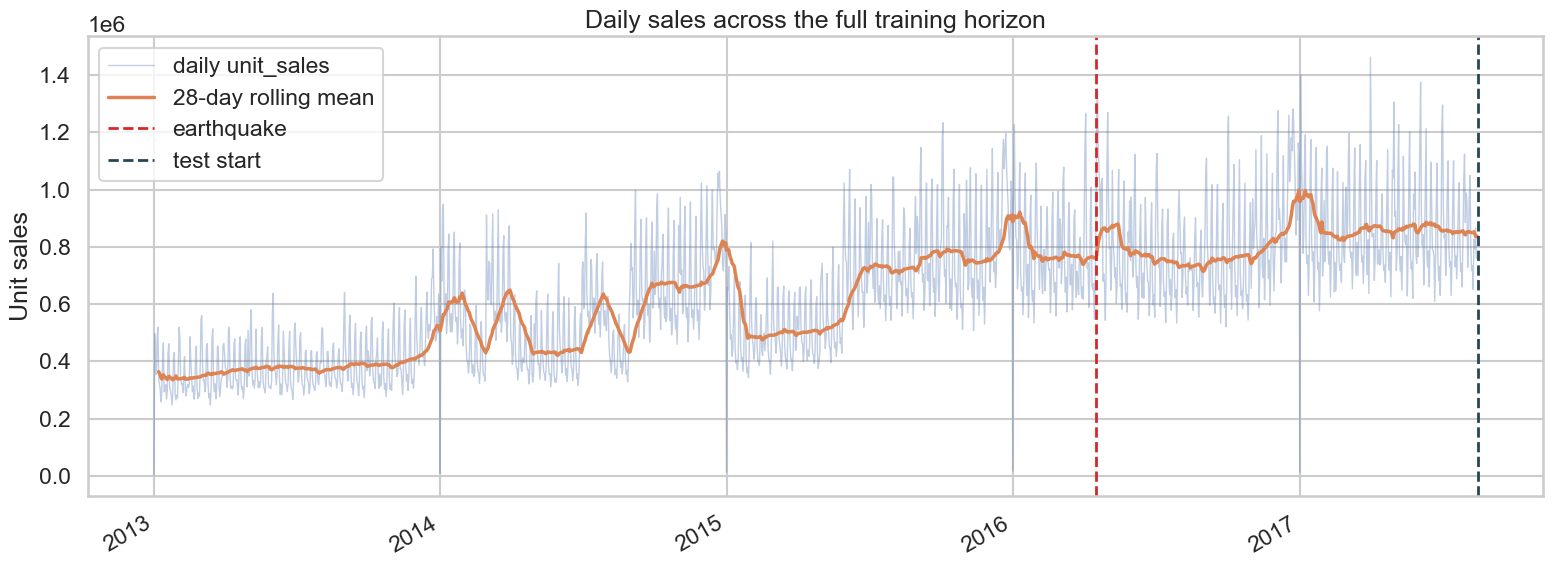

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))

daily_frame["unit_sales"].plot(ax=ax, alpha=0.35, linewidth=1, label="daily unit_sales")
daily_frame["rolling_28d"].plot(ax=ax, linewidth=2.5, label="28-day rolling mean")

ax.axvline(pd.Timestamp("2016-04-16"), color="#d62828", linestyle="--", linewidth=2, label="earthquake")
ax.axvline(test["date"].min(), color="#264653", linestyle="--", linewidth=2, label="test start")
ax.set_title("Daily sales across the full training horizon")
ax.set_xlabel("")
ax.set_ylabel("Unit sales")
ax.legend()

plt.tight_layout()
plt.show()

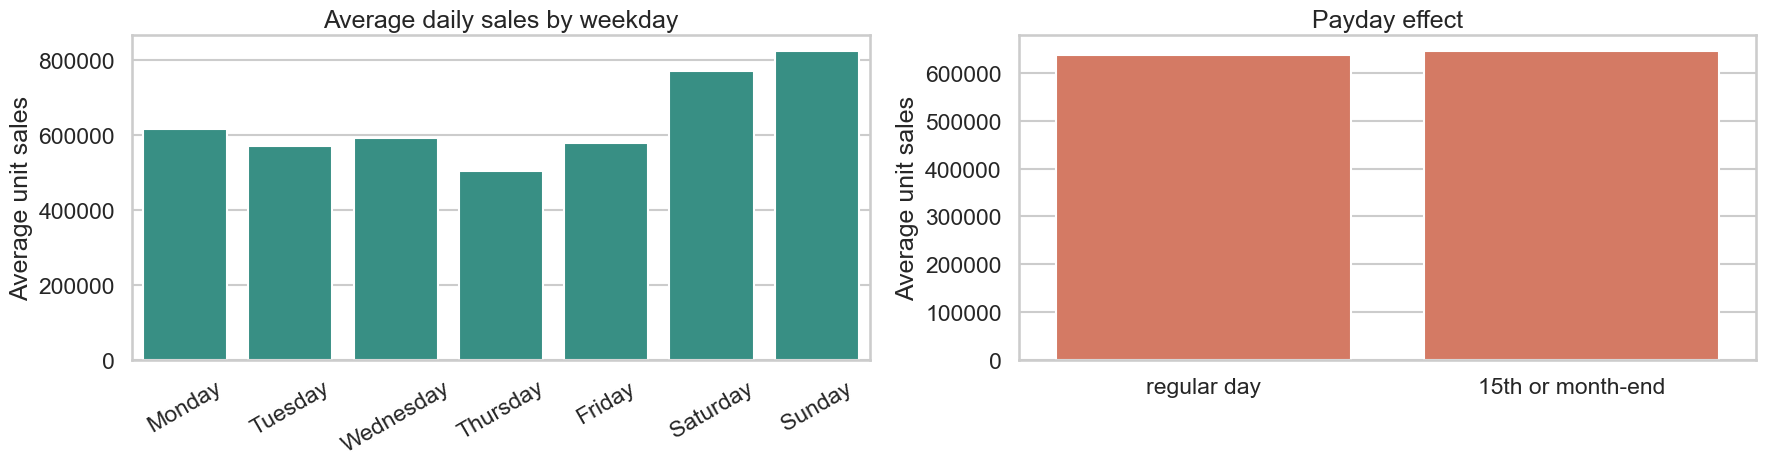

In [6]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_profile = daily_frame.groupby("weekday", as_index=False)["unit_sales"].mean()
weekday_profile["weekday"] = pd.Categorical(weekday_profile["weekday"], categories=weekday_order, ordered=True)
weekday_profile = weekday_profile.sort_values("weekday")

payday_profile = daily_frame.groupby("is_payday", as_index=False)["unit_sales"].mean()
payday_profile["bucket"] = payday_profile["is_payday"].map(
    {False: "regular day", True: "15th or month-end"}
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(data=weekday_profile, x="weekday", y="unit_sales", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Average daily sales by weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average unit sales")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=payday_profile, x="bucket", y="unit_sales", ax=axes[1], color="#e76f51")
axes[1].set_title("Payday effect")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average unit sales")

plt.tight_layout()
plt.show()

,unit_sales,transactions,dcoilwtico
unit_sales,1.000,0.677,-0.627
transactions,0.677,1.000,-0.245
dcoilwtico,-0.627,-0.245,1.000


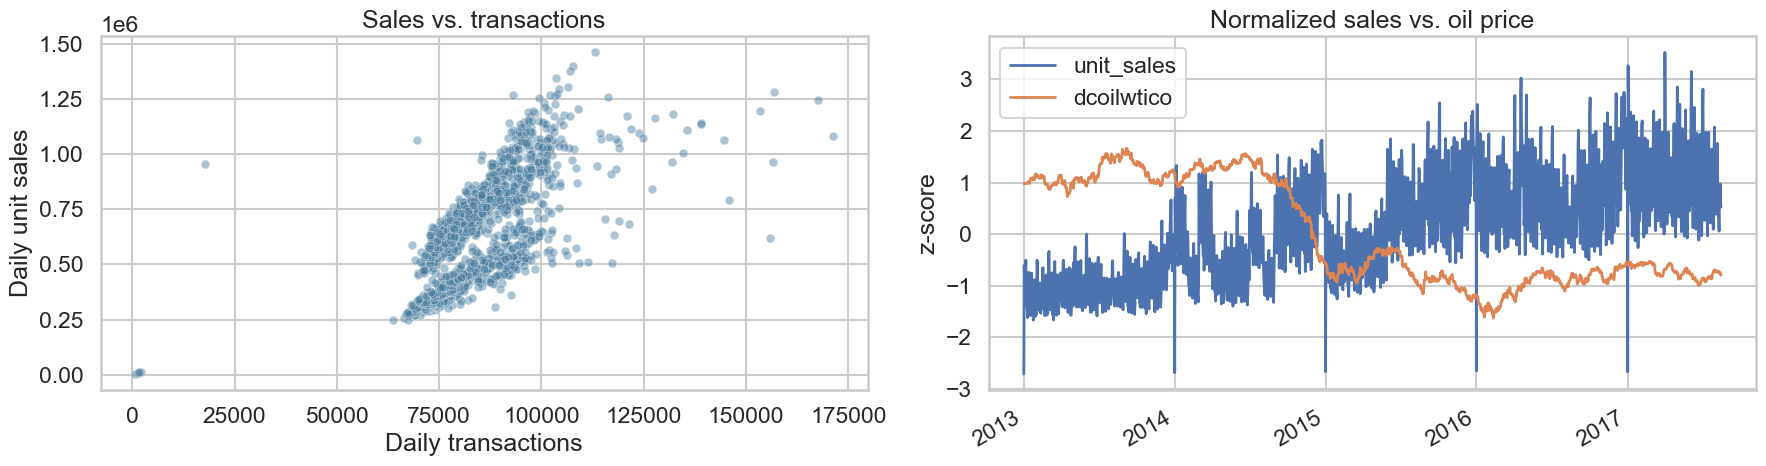

In [7]:
corr = daily_frame[["unit_sales", "transactions", "dcoilwtico"]].corr()
display(corr)

normalized = daily_frame[["unit_sales", "dcoilwtico"]].dropna().apply(
    lambda column: (column - column.mean()) / column.std()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.scatterplot(
    data=daily_frame,
    x="transactions",
    y="unit_sales",
    alpha=0.45,
    s=40,
    ax=axes[0],
    color="#457b9d",
)
axes[0].set_title("Sales vs. transactions")
axes[0].set_xlabel("Daily transactions")
axes[0].set_ylabel("Daily unit sales")

normalized.plot(ax=axes[1], linewidth=2)
axes[1].set_title("Normalized sales vs. oil price")
axes[1].set_xlabel("")
axes[1].set_ylabel("z-score")

plt.tight_layout()
plt.show()

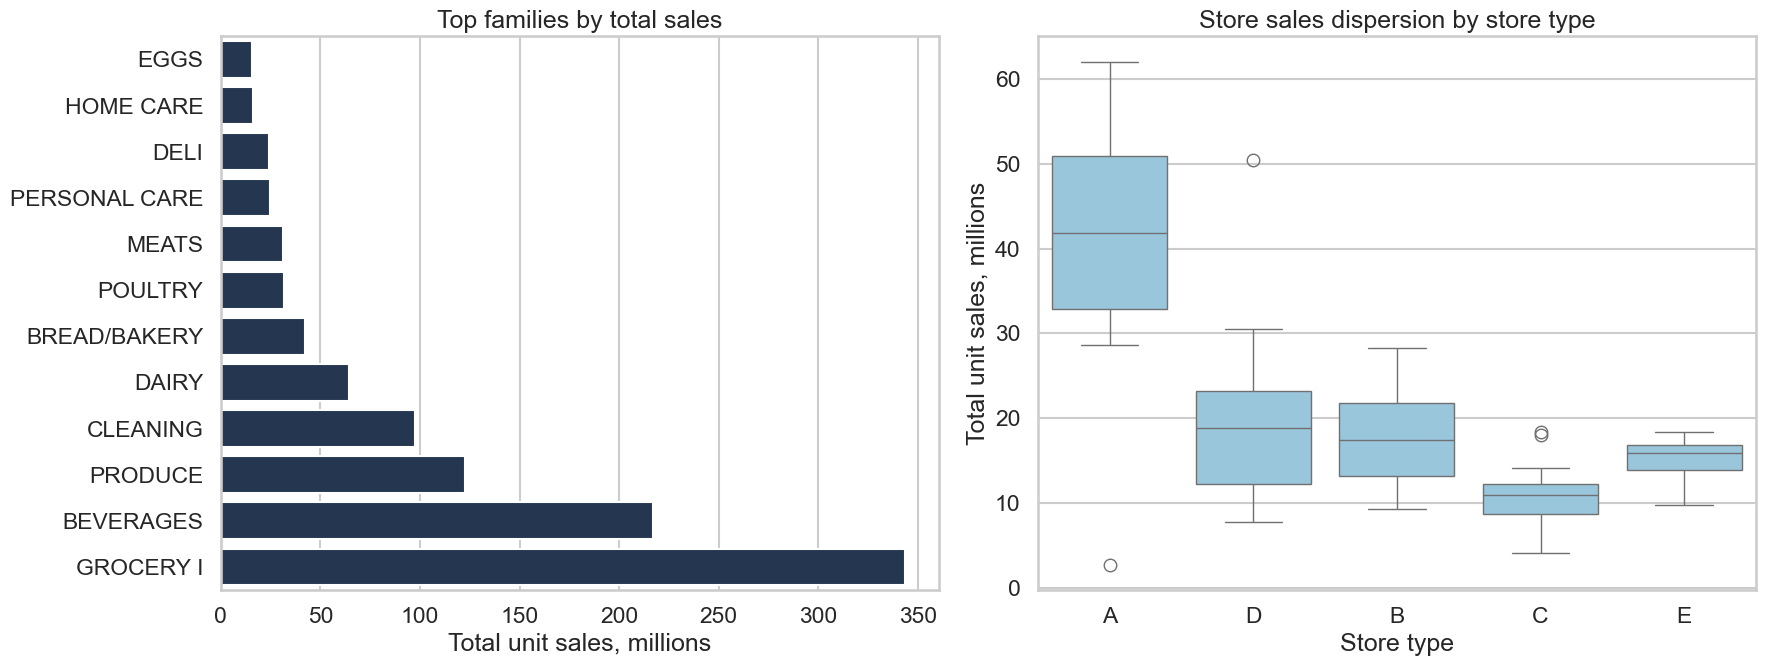

,store_nbr,city,state,type,cluster,unit_sales,sales_share
0,44,Quito,Pichincha,A,5,"62,087,540.000",0.058
1,45,Quito,Pichincha,A,11,"54,498,012.000",0.051
2,47,Quito,Pichincha,A,14,"50,948,312.000",0.047
3,3,Quito,Pichincha,D,8,"50,481,896.000",0.047
4,49,Quito,Pichincha,A,11,"43,420,092.000",0.040
5,46,Quito,Pichincha,A,14,"41,896,052.000",0.039
6,48,Quito,Pichincha,A,14,"35,933,128.000",0.033
7,51,Guayaquil,Guayas,A,17,"32,911,488.000",0.031
8,8,Quito,Pichincha,D,8,"30,491,330.000",0.028
9,50,Ambato,Tungurahua,A,14,"28,653,018.000",0.027


In [8]:
top_families = family_sales.nlargest(12, "unit_sales").sort_values("unit_sales")
top_families["unit_sales_mn"] = top_families["unit_sales"] / 1_000_000

store_plot = store_sales.copy()
store_plot["unit_sales_mn"] = store_plot["unit_sales"] / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=top_families, x="unit_sales_mn", y="family", ax=axes[0], color="#1d3557")
axes[0].set_title("Top families by total sales")
axes[0].set_xlabel("Total unit sales, millions")
axes[0].set_ylabel("")

sns.boxplot(data=store_plot, x="type", y="unit_sales_mn", ax=axes[1], color="#8ecae6")
axes[1].set_title("Store sales dispersion by store type")
axes[1].set_xlabel("Store type")
axes[1].set_ylabel("Total unit sales, millions")

plt.tight_layout()
plt.show()

display(
    store_sales.head(10)[
        ["store_nbr", "city", "state", "type", "cluster", "unit_sales", "sales_share"]
    ]
)

locale,Local,National,Regional
type,,,
Additional,11,40,0
Bridge,0,5,0
Event,0,56,0
Holiday,137,60,24
Transfer,4,8,0
Work Day,0,5,0


,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True


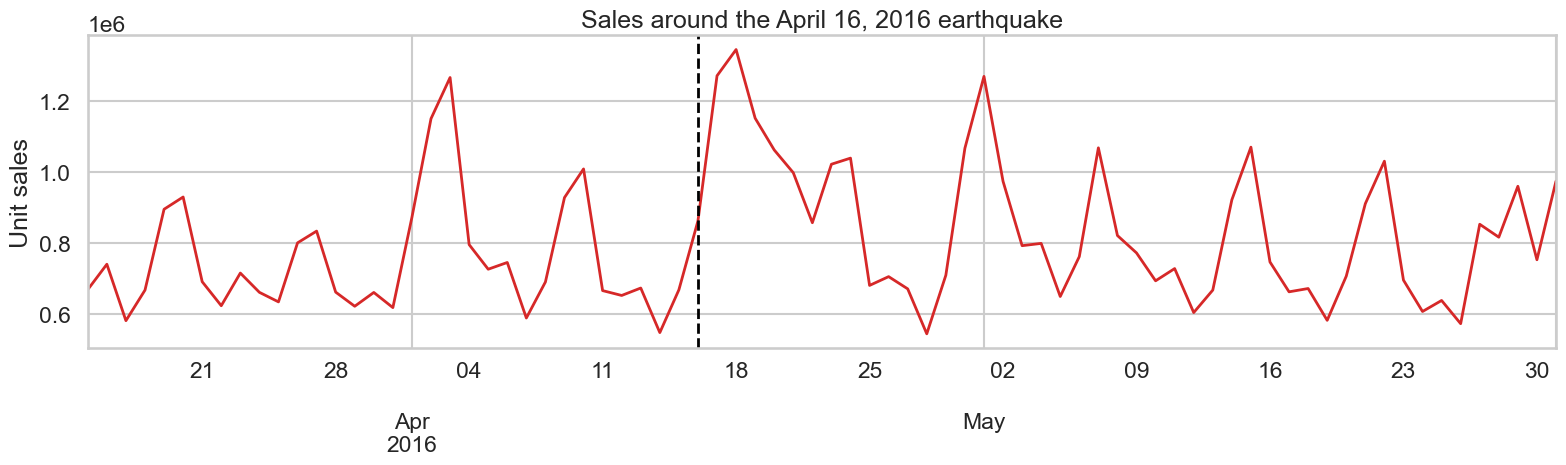

In [9]:
holiday_pivot = holidays.groupby(["type", "locale"]).size().unstack(fill_value=0)
transferred_examples = holidays.loc[
    holidays["transferred"],
    ["date", "type", "locale", "locale_name", "description", "transferred"],
].head(10)

earthquake_window = daily_frame.loc["2016-03-15":"2016-05-31", ["unit_sales"]]

display(holiday_pivot)
display(transferred_examples)

fig, ax = plt.subplots(figsize=(16, 5))
earthquake_window["unit_sales"].plot(ax=ax, linewidth=2, color="#d62828")
ax.axvline(pd.Timestamp("2016-04-16"), color="black", linestyle="--", linewidth=2)
ax.set_title("Sales around the April 16, 2016 earthquake")
ax.set_xlabel("")
ax.set_ylabel("Unit sales")

plt.tight_layout()
plt.show()

## Holdout validation и baseline-модели

Ниже используем простую time-based валидацию:
- validation horizon = последние 16 дней train, то есть с `2017-07-31` по `2017-08-15`;
- fit window = предыдущие 112 дней;
- метрика = weighted RMSLE с весами `1.25` для perishable и `1.0` иначе.

Ограничение валидации:
- в `train.csv` отсутствуют нулевые продажи, поэтому holdout ниже считается только на наблюдаемых строках;
- это полезный относительный sanity check для baseline-моделей, но не идеальная реплика Kaggle leaderboard.

In [10]:
baseline_artifacts = build_baseline_validation_artifacts(DATA_DIR)
baseline_meta = pd.DataFrame(
    [
        {"metric": "fit_start", "value": str(baseline_artifacts["metadata"]["fit_start"].date())},
        {"metric": "valid_start", "value": str(baseline_artifacts["metadata"]["valid_start"].date())},
        {"metric": "valid_end", "value": str(baseline_artifacts["metadata"]["valid_end"].date())},
        {"metric": "fit_rows", "value": f"{baseline_artifacts['metadata']['fit_rows']:,}"},
        {"metric": "valid_rows_observed_only", "value": f"{baseline_artifacts['metadata']['valid_rows']:,}"},
        {"metric": "global_mean_target", "value": f"{baseline_artifacts['metadata']['global_mean']:.3f}"},
    ]
)
display(baseline_meta)

,metric,value
0,fit_start,2017-04-10
1,valid_start,2017-07-31
2,valid_end,2017-08-15
3,fit_rows,"11,847,653"
4,valid_rows_observed_only,"1,677,344"
5,global_mean_target,8.100


In [11]:
baseline_recent_mean = predict_recent_mean_baseline(baseline_artifacts)
baseline_hierarchical = predict_hierarchical_baseline(baseline_artifacts)

baseline_scores = summarize_baseline_results(
    {
        "recent_mean_28d": baseline_recent_mean,
        "hierarchical_weekday_promo": baseline_hierarchical,
    }
)
display(baseline_scores)

source_mix = (
    baseline_hierarchical["source"]
    .value_counts(normalize=True)
    .rename("row_share")
    .reset_index()
    .rename(columns={"index": "source"})
)
display(source_mix)

,baseline,weighted_rmsle,mean_prediction,mean_actual
0,hierarchical_weekday_promo,0.553,7.824,7.941
1,recent_mean_28d,0.568,8.052,7.941


,source,row_share
0,store_item_weekday_promo,0.955
1,store_item_weekday,0.030
2,family_store_weekday_promo,0.014
3,family_store_weekday,0.000
4,family_weekday_promo,0.000


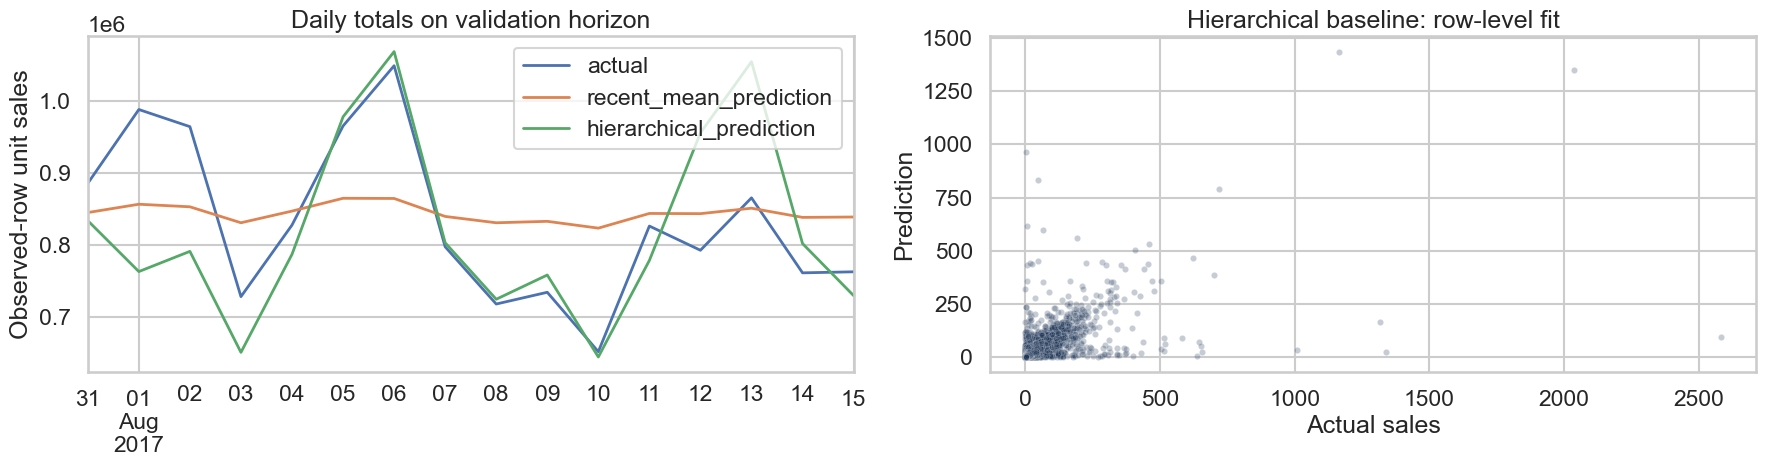

In [12]:
baseline_daily = (
    baseline_hierarchical.groupby("date", as_index=False)[["actual", "prediction"]]
    .sum()
    .rename(columns={"prediction": "hierarchical_prediction"})
)
baseline_daily = baseline_daily.merge(
    baseline_recent_mean.groupby("date", as_index=False)["prediction"].sum(),
    on="date",
    how="left",
).rename(columns={"prediction": "recent_mean_prediction"})

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

baseline_daily.plot(
    x="date",
    y=["actual", "recent_mean_prediction", "hierarchical_prediction"],
    ax=axes[0],
    linewidth=2,
)
axes[0].set_title("Daily totals on validation horizon")
axes[0].set_xlabel("")
axes[0].set_ylabel("Observed-row unit sales")

sns.scatterplot(
    data=baseline_hierarchical.sample(min(100_000, len(baseline_hierarchical)), random_state=42),
    x="actual",
    y="prediction",
    alpha=0.25,
    s=20,
    ax=axes[1],
    color="#1d3557",
)
axes[1].set_title("Hierarchical baseline: row-level fit")
axes[1].set_xlabel("Actual sales")
axes[1].set_ylabel("Prediction")

plt.tight_layout()
plt.show()

## Первая обучаемая модель: feature-based LightGBM

После lookup-baseline следующий логичный шаг:
- взять тот же holdout;
- собрать табличные признаки по календарю, promotions, metadata, holidays, oil и transactions;
- добавить исторические средние по `store-item` и `family`;
- обучить первую компактную `LightGBM`-модель на `log1p(unit_sales)`.

Ограничение этого шага:
- `transactions` доступны только на train-периоде;
- значит этот блок пока решает задачу validation/prototyping, а не готовый Kaggle inference pipeline.

In [13]:
lgbm_result = run_lightgbm_validation_experiment(DATA_DIR)

lgbm_meta = pd.DataFrame(
    [
        {"metric": "fit_start", "value": str(lgbm_result["metadata"]["fit_start"].date())},
        {"metric": "valid_start", "value": str(lgbm_result["metadata"]["valid_start"].date())},
        {"metric": "valid_end", "value": str(lgbm_result["metadata"]["valid_end"].date())},
        {"metric": "fit_rows", "value": f"{lgbm_result['metadata']['fit_rows']:,}"},
        {"metric": "valid_rows", "value": f"{lgbm_result['metadata']['valid_rows']:,}"},
        {"metric": "n_features", "value": len(lgbm_result["feature_importance"])},
    ]
)

display(lgbm_meta)
display(lgbm_result["scores"])
display(lgbm_result["feature_importance"].head(12))

,metric,value
0,fit_start,2017-04-10
1,valid_start,2017-07-31
2,valid_end,2017-08-15
3,fit_rows,"11,847,653"
4,valid_rows,"1,677,344"
5,n_features,29


,model,weighted_rmsle
0,lightgbm_feature_model,0.515
1,hierarchical_weekday_promo,0.553
2,recent_mean_28d,0.568


,feature,importance_gain,importance_split
0,siw_mean,"40,742,450.486",2291
1,si_recent28,"2,554,833.582",1645
2,item_code,"1,952,664.257",20912
3,onpromotion,"465,767.177",745
4,day,"210,756.303",1382
5,store_code,"163,761.271",3686
6,weekofyear,"129,816.588",1279
7,family_code,"102,898.130",847
8,weekday,"95,263.760",794
9,transactions,"84,743.874",930


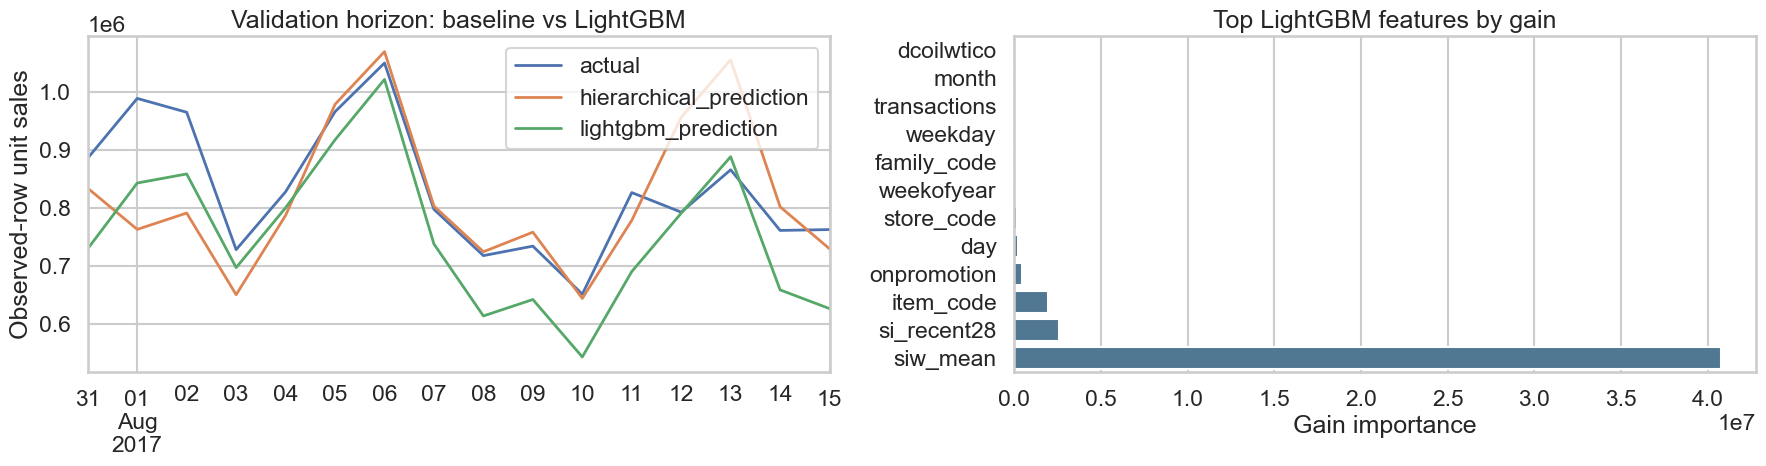

In [14]:
lgbm_daily = lgbm_result["daily_validation"].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

lgbm_daily.plot(
    x="date",
    y=["actual", "hierarchical_prediction", "lightgbm_prediction"],
    ax=axes[0],
    linewidth=2,
)
axes[0].set_title("Validation horizon: baseline vs LightGBM")
axes[0].set_xlabel("")
axes[0].set_ylabel("Observed-row unit sales")

top_gain = lgbm_result["feature_importance"].head(12).sort_values("importance_gain")
sns.barplot(data=top_gain, x="importance_gain", y="feature", ax=axes[1], color="#457b9d")
axes[1].set_title("Top LightGBM features by gain")
axes[1].set_xlabel("Gain importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Полноценная стратегия для временных рядов: rolling-origin CV

Для реального обучения одной последней валидации мало, поэтому ниже используется более строгая схема:
- horizon = 16 дней, как в `test.csv`;
- 4 rolling-origin fold'а с шагом 28 дней;
- grid по lookback-окнам `112` и `224` дней;
- основной pipeline строится **без `transactions`**, чтобы модель была применима на test-time;
- вся доступная история train дополнительно используется через full-history aggregate priors.

Важная инженерная оговорка:
- скармливать все 125M observed rows в один raw fit здесь хуже и по памяти, и по статистике;
- для нестационарного retail-ряда разумнее подобрать рабочее окно истории через rolling CV, а старую историю использовать как priors/backoff-признаки.

In [15]:
tscv_result = run_time_series_cross_validation(
    DATA_DIR,
    lookback_grid=(112, 224),
    horizon_days=16,
    step_days=28,
    n_folds=4,
    include_transactions=False,
)

tscv_meta = pd.DataFrame(
    [
        {"metric": "best_lookback_days", "value": int(tscv_result["metadata"]["best_lookback_days"])},
        {"metric": "best_mean_wrmsle", "value": f"{tscv_result['metadata']['best_mean_score']:.6f}"},
        {"metric": "n_folds", "value": tscv_result["metadata"]["n_folds"]},
        {"metric": "horizon_days", "value": tscv_result["metadata"]["horizon_days"]},
        {"metric": "step_days", "value": tscv_result["metadata"]["step_days"]},
    ]
)

display(tscv_meta)
display(tscv_result["summary"])
display(tscv_result["fold_scores"])
display(tscv_result["feature_importance_summary"].head(15))

,metric,value
0,best_lookback_days,224
1,best_mean_wrmsle,0.511284
2,n_folds,4
3,horizon_days,16
4,step_days,28


,lookback_days,mean_score,std_score,min_score,max_score
0,224,0.511,0.003,0.508,0.515
1,112,0.516,0.004,0.512,0.521


,fold,valid_start,valid_end,lookback_days,fit_rows,valid_rows,weighted_rmsle
0,fold_1,2017-05-08,2017-05-23,112,11773085,1685493,0.521
1,fold_2,2017-06-05,2017-06-20,112,11824304,1680802,0.512
2,fold_3,2017-07-03,2017-07-18,112,11841903,1688043,0.513
3,fold_4,2017-07-31,2017-08-15,112,11847653,1677344,0.516
4,fold_1,2017-05-08,2017-05-23,224,22879011,1685493,0.515
5,fold_2,2017-06-05,2017-06-20,224,23146634,1680802,0.508
6,fold_3,2017-07-03,2017-07-18,224,23344024,1688043,0.509
7,fold_4,2017-07-31,2017-08-15,224,23426907,1677344,0.513


,feature,importance_gain,importance_split
0,siw_mean,"53,561,013.295","1,792.375"
1,si_all_mean,"5,975,466.390","1,094.000"
2,si_recent56,"3,329,080.076","1,228.875"
3,item_code,"2,547,527.422","17,809.125"
4,onpromotion,"824,218.671",790.875
5,si_recent28,"421,734.288","1,175.500"
6,day,"399,672.269","1,633.125"
7,store_code,"339,766.960","4,143.375"
8,weekday,"311,119.145",840.250
9,weekofyear,"299,330.826","1,679.250"


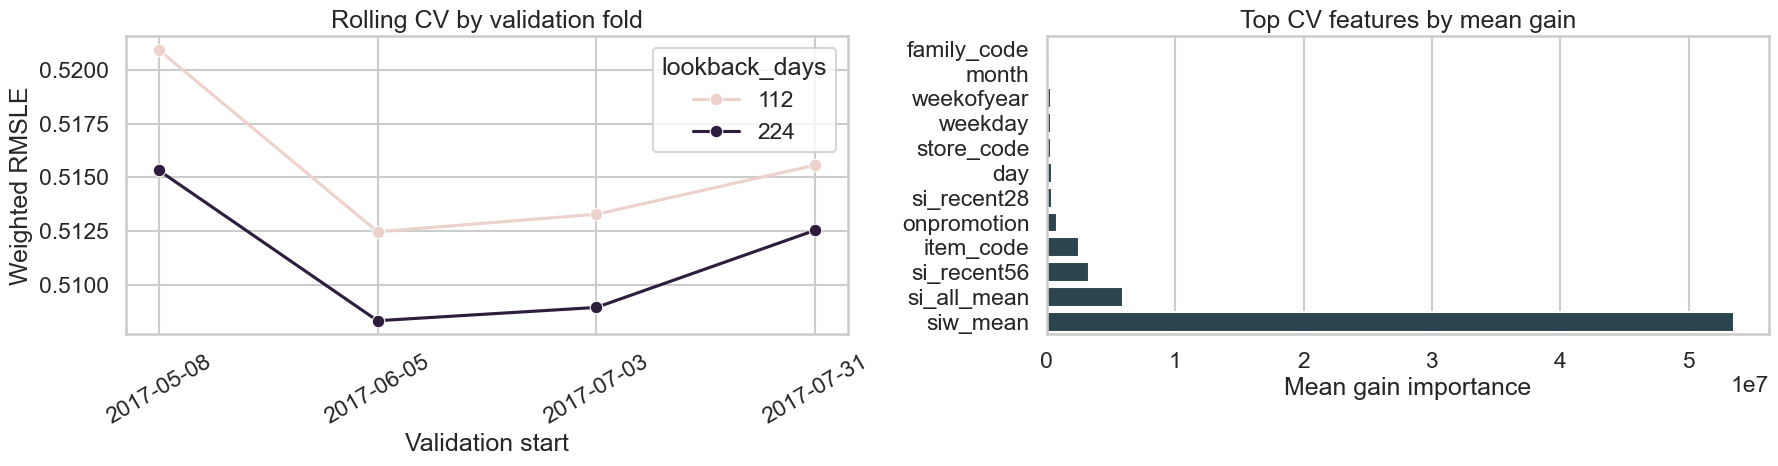

In [16]:
cv_plot = tscv_result["fold_scores"].copy()
cv_plot["valid_start"] = cv_plot["valid_start"].dt.strftime("%Y-%m-%d")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.lineplot(
    data=cv_plot,
    x="valid_start",
    y="weighted_rmsle",
    hue="lookback_days",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Rolling CV by validation fold")
axes[0].set_xlabel("Validation start")
axes[0].set_ylabel("Weighted RMSLE")
axes[0].tick_params(axis="x", rotation=30)

top_cv_gain = tscv_result["feature_importance_summary"].head(12).sort_values("importance_gain")
sns.barplot(data=top_cv_gain, x="importance_gain", y="feature", ax=axes[1], color="#264653")
axes[1].set_title("Top CV features by mean gain")
axes[1].set_xlabel("Mean gain importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Финальное обучение и inference на `test.csv`

После CV модель обучается заново на train до `2017-08-15` с лучшим окном истории и тем же test-time-safe feature set.
Результат сохраняется сразу в Kaggle-ready submission.

In [17]:
final_model_result = train_final_time_series_model(
    DATA_DIR,
    lookback_days=tscv_result["metadata"]["best_lookback_days"],
    include_transactions=False,
)

final_meta = pd.DataFrame(
    [
        {"metric": "fit_start", "value": str(final_model_result["metadata"]["fit_start"].date())},
        {"metric": "train_end", "value": str(final_model_result["metadata"]["train_end"].date())},
        {"metric": "test_start", "value": str(final_model_result["metadata"]["test_start"].date())},
        {"metric": "test_end", "value": str(final_model_result["metadata"]["test_end"].date())},
        {"metric": "fit_rows", "value": f"{final_model_result['metadata']['fit_rows']:,}"},
        {"metric": "submission_path", "value": final_model_result["metadata"]["submission_path"]},
    ]
)

display(final_meta)
display(final_model_result["feature_importance"].head(15))
display(final_model_result["submission_head"])

,metric,value
0,fit_start,2017-01-03
1,train_end,2017-08-15
2,test_start,2017-08-16
3,test_end,2017-08-31
4,fit_rows,"23,692,343"
5,submission_path,Z:\Programming\MscAI\TimeSeries\hw3\submission...


,feature,importance_gain,importance_split
0,siw_mean,"81,782,756.071",1947
1,item_code,"3,054,005.401",17175
2,si_all_mean,"2,025,954.913",1198
3,onpromotion,"1,102,333.876",875
4,day,"520,033.761",1649
5,si_recent56,"471,322.705",1168
6,store_code,"386,083.387",4053
7,si_recent28,"363,983.392",1137
8,weekofyear,"354,066.654",1780
9,family_code,"268,291.414",733


,id,unit_sales
0,125497040,1.106
1,125497041,1.572
2,125497042,1.012
3,125497043,1.860
4,125497044,2.733
5,125497045,6.287
6,125497046,10.394
7,125497047,0.943
8,125497048,1.864
9,125497049,1.277


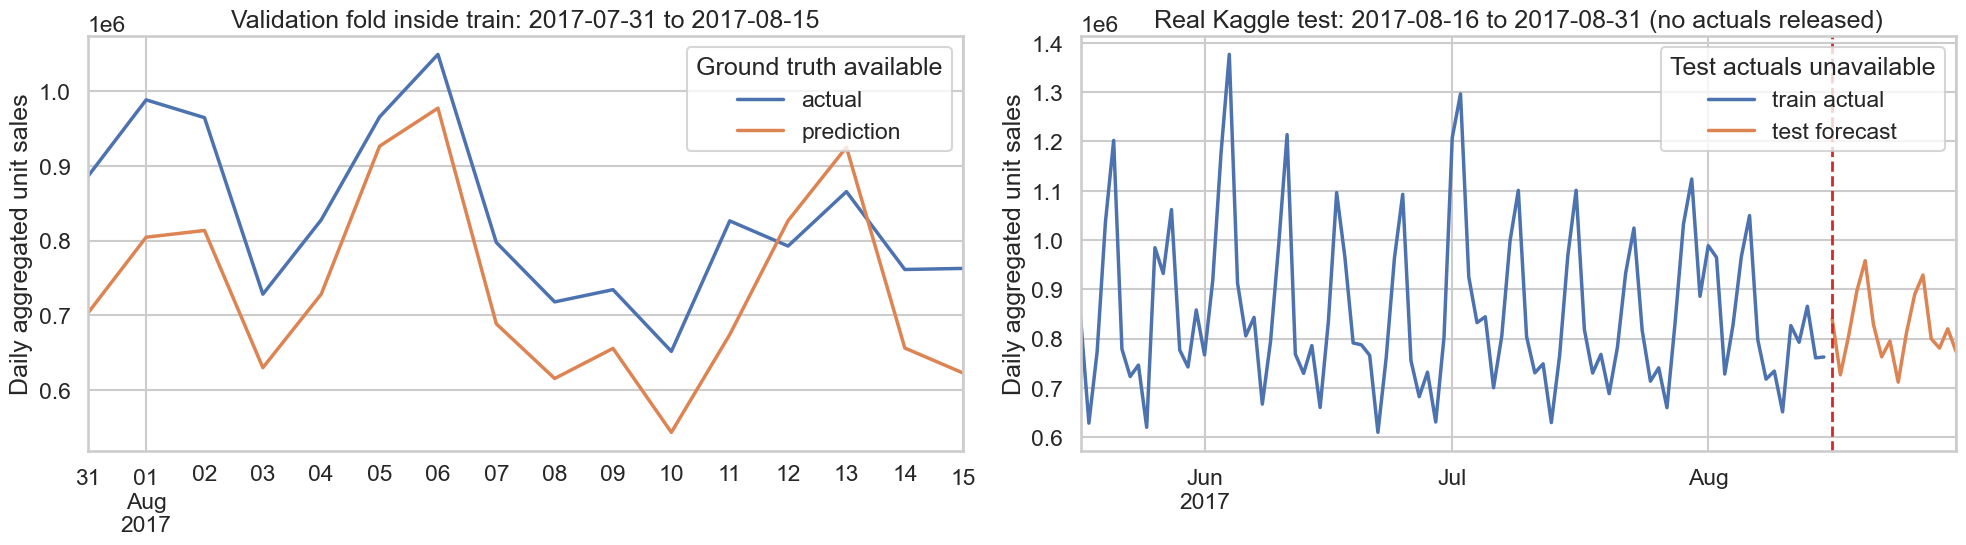

In [18]:
latest_fold_start = tscv_result["folds"]["valid_start"].max()
latest_fold_result = run_single_fold_time_series_experiment(
    valid_start=latest_fold_start,
    lookback_days=tscv_result["metadata"]["best_lookback_days"],
    include_transactions=False,
)

submission_frame = pd.read_csv(final_model_result["metadata"]["submission_path"], compression="gzip")
test_submission_index = pd.read_csv(DATA_DIR / "test.csv", usecols=["id", "date"], parse_dates=["date"])
forecast_daily = (
    test_submission_index
    .merge(submission_frame, on="id", how="left")
    .groupby("date", as_index=False)["unit_sales"]
    .sum()
    .rename(columns={"unit_sales": "forecast_unit_sales"})
)

history_cutoff = pd.Timestamp(final_model_result["metadata"]["train_end"]) - pd.Timedelta(days=90)
history_window = daily_sales.reset_index()[["date", "unit_sales"]].rename(
    columns={"unit_sales": "actual_unit_sales"}
)
history_window = history_window[history_window["date"] >= history_cutoff].copy()
validation_daily = latest_fold_result["daily_validation"].copy()
validation_end = validation_daily["date"].max()
test_start = pd.Timestamp(final_model_result["metadata"]["test_start"])
test_end = pd.Timestamp(final_model_result["metadata"]["test_end"])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

validation_daily.plot(
    x="date",
    y=["actual", "prediction"],
    ax=axes[0],
    linewidth=2.5,
)
axes[0].set_title(
    f"Validation fold inside train: {latest_fold_start.date()} to {validation_end.date()}"
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Daily aggregated unit sales")
axes[0].legend(title="Ground truth available")

history_window.plot(x="date", y="actual_unit_sales", ax=axes[1], linewidth=2.5, label="train actual")
forecast_daily.plot(x="date", y="forecast_unit_sales", ax=axes[1], linewidth=2.5, label="test forecast")
axes[1].axvline(
    test_start,
    color="#d62828",
    linestyle="--",
    linewidth=2,
)
axes[1].set_title(
    f"Real Kaggle test: {test_start.date()} to {test_end.date()} (no actuals released)"
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Daily aggregated unit sales")
axes[1].legend(title="Test actuals unavailable")

plt.tight_layout()
plt.show()

## Текущая боевая стратегия: CatBoost + pseudo-public validation

После загрузки `LightGBM` submission на Kaggle стало ясно, что observed-row holdout слишком оптимистичен.
Поэтому ниже:

- используем full-panel validation на реальных `store-item` парах из `test.csv`;
- считаем агрегаты по полному observed fit;
- сам `CatBoost` обучаем на sampled recent train;
- отдельно держим `Optuna`, но короткий поиск пока служит скорее infrastructure check, чем финальным тюнингом.

In [19]:
catboost_params = NOTEBOOK_CATBOOST_SINGLE_FOLD_PARAMS.copy()
catboost_postprocess = DEFAULT_CATBOOST_POSTPROCESS_PARAMS.copy()

display(pd.DataFrame([catboost_params]))
display(pd.DataFrame([catboost_postprocess]))

catboost_single_fold = run_single_fold_catboost_experiment(
    valid_start=latest_fold_start,
    lookback_days=224,
    fit_max_rows=300_000,
    eval_max_rows=120_000,
    zero_sample_size=80_000,
    zero_sample_days=28,
    model_params=catboost_params,
    history_scale=catboost_postprocess["history_scale"],
    min_model_weight=catboost_postprocess["min_model_weight"],
    unseen_model_weight=catboost_postprocess["unseen_model_weight"],
)

catboost_meta = pd.DataFrame(
    [
        {"metric": "fit_start", "value": str(catboost_single_fold["metadata"]["fit_start"].date())},
        {"metric": "valid_start", "value": str(catboost_single_fold["metadata"]["valid_start"].date())},
        {"metric": "valid_end", "value": str(catboost_single_fold["metadata"]["valid_end"].date())},
        {"metric": "fit_observed_rows", "value": f"{catboost_single_fold['metadata']['fit_observed_rows']:,}"},
        {"metric": "fit_train_rows", "value": f"{catboost_single_fold['metadata']['fit_train_rows']:,}"},
        {"metric": "valid_rows_full_panel", "value": f"{catboost_single_fold['metadata']['valid_rows']:,}"},
        {"metric": "raw_catboost_wrmsle", "value": f"{catboost_single_fold['raw_model_score']:.6f}"},
        {"metric": "final_score_with_current_postprocess", "value": f"{catboost_single_fold['score']:.6f}"},
    ]
)

display(catboost_meta)
display(catboost_single_fold["feature_importance"].head(15))


,iterations,depth,learning_rate,border_count,verbose
0,120,8,0.050,128,False


,history_scale,min_model_weight,unseen_model_weight
0,3.000,1.000,1.000


,metric,value
0,fit_start,2016-12-19
1,valid_start,2017-07-31
2,valid_end,2017-08-15
3,fit_observed_rows,"23,426,907"
4,fit_train_rows,"300,000"
5,valid_rows_full_panel,"3,370,464"
6,raw_catboost_wrmsle,0.582715
7,final_score_with_current_postprocess,0.582715


,feature,importance
0,si_recent28,34.973
1,siw_mean,20.577
2,siw_count_log,13.699
3,onpromotion,7.679
4,recent_ratio_28_56,5.718
5,si_recent56,4.970
6,dcoilwtico,3.194
7,day,2.318
8,weekday,1.346
9,is_weekend,0.901


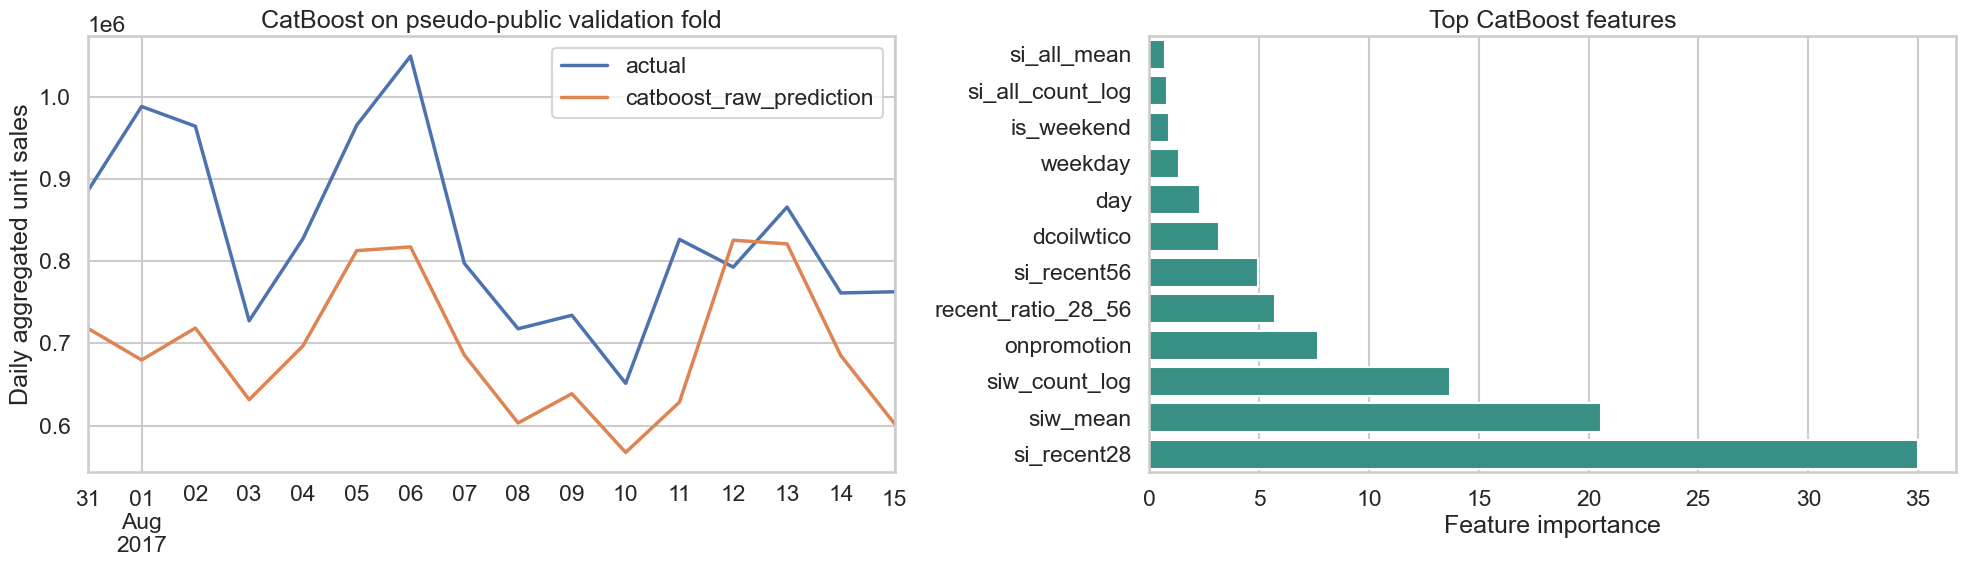

In [20]:
catboost_daily = catboost_single_fold["daily_validation"].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

catboost_daily.plot(
    x="date",
    y=["actual", "catboost_raw_prediction"],
    ax=axes[0],
    linewidth=2.5,
)
axes[0].set_title("CatBoost on pseudo-public validation fold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Daily aggregated unit sales")

top_cb_gain = catboost_single_fold["feature_importance"].head(12).sort_values("importance")
sns.barplot(data=top_cb_gain, x="importance", y="feature", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Top CatBoost features")
axes[1].set_xlabel("Feature importance")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [21]:
catboost_optuna = run_catboost_optuna_search(
    lookback_days=224,
    fit_max_rows=300_000,
    eval_max_rows=120_000,
    zero_sample_size=80_000,
    zero_sample_days=28,
    n_trials=2,
)

display(pd.DataFrame([catboost_optuna["best_postprocess"]]))
display(pd.DataFrame([catboost_optuna["best_model_params"]]))
display(catboost_optuna["trials"])

,history_scale,min_model_weight,unseen_model_weight
0,5.398,0.940,0.708


,loss_function,eval_metric,iterations,learning_rate,depth,l2_leaf_reg,random_strength,bagging_temperature,border_count,bootstrap_type,grow_policy,random_seed,allow_writing_files,verbose,thread_count
0,RMSE,RMSE,662,0.110,9,6.010,0.026,0.468,75,Bayesian,SymmetricTree,42,False,False,-1


,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_border_count,params_depth,params_history_scale,params_iterations,params_l2_leaf_reg,params_learning_rate,params_min_model_weight,params_random_strength,params_unseen_model_weight,user_attrs_best_iteration,user_attrs_score,state
0,0,0.608,2026-03-17 19:45:05.135357,2026-03-17 19:45:15.044501,0 days 00:00:09.909144,0.468,75,9,5.398,662,6.010,0.110,0.940,0.026,0.708,31,0.608,COMPLETE
1,1,0.647,2026-03-17 19:45:15.044539,2026-03-17 19:45:26.996829,0 days 00:00:11.952290,0.550,122,10,3.861,414,1.889,0.114,0.915,0.031,0.291,31,0.647,COMPLETE


In [22]:
catboost_params = NOTEBOOK_CATBOOST_SINGLE_FOLD_PARAMS.copy()
catboost_postprocess = DEFAULT_CATBOOST_POSTPROCESS_PARAMS.copy()

catboost_final = train_final_catboost_model(
    lookback_days=224,
    fit_max_rows=300_000,
    zero_sample_size=80_000,
    zero_sample_days=28,
    model_params=catboost_params,
    postprocess_params=catboost_postprocess,
)

catboost_final_meta = pd.DataFrame(
    [
        {"metric": "fit_start", "value": str(catboost_final["metadata"]["fit_start"].date())},
        {"metric": "train_end", "value": str(catboost_final["metadata"]["train_end"].date())},
        {"metric": "test_start", "value": str(catboost_final["metadata"]["test_start"].date())},
        {"metric": "test_end", "value": str(catboost_final["metadata"]["test_end"].date())},
        {"metric": "fit_observed_rows", "value": f"{catboost_final['metadata']['fit_observed_rows']:,}"},
        {"metric": "fit_train_rows", "value": f"{catboost_final['metadata']['fit_train_rows']:,}"},
        {"metric": "submission_path", "value": catboost_final["metadata"]["submission_path"]},
    ]
)

display(catboost_final_meta)
display(catboost_final["feature_importance"].head(15))
display(catboost_final["submission_head"])
display(catboost_final["unseen_summary"])


,metric,value
0,fit_start,2017-01-03
1,train_end,2017-08-15
2,test_start,2017-08-16
3,test_end,2017-08-31
4,fit_observed_rows,"23,692,343"
5,fit_train_rows,"300,000"
6,submission_path,/Users/kaidan/Documents/HSE/timeseries/hw3/sub...


,feature,importance
0,si_recent28,35.503
1,siw_mean,20.518
2,siw_count_log,16.305
3,onpromotion,8.061
4,recent_ratio_28_56,6.126
5,si_recent56,5.132
6,si_all_mean,1.969
7,si_all_count_log,0.802
8,dcoilwtico,0.742
9,day,0.741


,id,unit_sales
0,125497040,0.502
1,125497041,0.824
2,125497042,0.020
3,125497043,1.339
4,125497044,2.159
5,125497045,5.186
6,125497046,8.047
7,125497047,0.009
8,125497048,1.223
9,125497049,0.454


,unseen_item_flag,count,mean_unit_sales
0,0,3318624,3.175
1,1,51840,0.010


## TFT report (artifacts only, no execution)

This section uses only ready files from `submissions/tft_final_v100_tuned_infer`:
- no training;
- no inference;
- report from `config.json`, `run_summary.json`, `test_predictions.csv.gz`, `submission_tft_*.csv.gz`.


In [23]:
from json import loads

TFT_REPORT_DIR = Path("submissions") / "tft_final_v100_tuned_infer"
tft_config_path = TFT_REPORT_DIR / "config.json"
tft_summary_path = TFT_REPORT_DIR / "run_summary.json"
tft_predictions_path = TFT_REPORT_DIR / "test_predictions.csv.gz"
tft_submission_path = TFT_REPORT_DIR / "submission_tft_lb224_enc56.csv.gz"

required_tft_files = [
    tft_config_path,
    tft_summary_path,
    tft_predictions_path,
    tft_submission_path,
]
missing_tft_files = [path for path in required_tft_files if not path.exists()]

tft_report_ready = len(missing_tft_files) == 0
if not tft_report_ready:
    print("TFT report skipped. Missing files:")
    for path in missing_tft_files:
        print(f"- {path}")
else:
    tft_config = loads(tft_config_path.read_text(encoding="utf-8"))
    tft_run_summary = loads(tft_summary_path.read_text(encoding="utf-8"))

    tft_run_meta = pd.DataFrame(
        [
            {"metric": "run_name", "value": tft_run_summary.get("run_name")},
            {"metric": "mode", "value": tft_run_summary.get("mode")},
            {"metric": "inference_only", "value": tft_run_summary.get("inference_only")},
            {"metric": "fit_start", "value": tft_run_summary["metadata"].get("fit_start")},
            {"metric": "train_end", "value": tft_run_summary["metadata"].get("train_end")},
            {"metric": "test_start", "value": tft_run_summary["metadata"].get("test_start")},
            {"metric": "test_end", "value": tft_run_summary["metadata"].get("test_end")},
            {"metric": "eligible_pairs", "value": tft_run_summary["metadata"].get("eligible_pairs")},
            {"metric": "fallback_pairs", "value": tft_run_summary["metadata"].get("fallback_pairs")},
            {"metric": "rows_used_fallback", "value": tft_run_summary["prediction_summary"].get("rows_used_fallback")},
            {"metric": "mean_final_prediction", "value": tft_run_summary["prediction_summary"].get("mean_final_prediction")},
        ]
    )

    tft_model_summary = pd.DataFrame([tft_run_summary.get("model_summary", {})])
    tft_config_view = pd.DataFrame(
        [
            {"param": "lookback_days", "value": tft_config.get("lookback_days")},
            {"param": "max_encoder_length", "value": tft_config.get("max_encoder_length")},
            {"param": "max_prediction_length", "value": tft_config.get("max_prediction_length")},
            {"param": "max_series", "value": tft_config.get("max_series")},
            {"param": "hidden_size", "value": tft_config.get("hidden_size")},
            {"param": "attention_head_size", "value": tft_config.get("attention_head_size")},
            {"param": "hidden_continuous_size", "value": tft_config.get("hidden_continuous_size")},
            {"param": "dropout", "value": tft_config.get("dropout")},
            {"param": "learning_rate", "value": tft_config.get("learning_rate")},
        ]
    )

    display(tft_run_meta)
    display(tft_model_summary)
    display(tft_config_view)


,metric,value
0,run_name,tft_final_v100_tuned_infer
1,mode,final
2,inference_only,True
3,fit_start,2017-01-03 00:00:00
4,train_end,2017-08-15 00:00:00
5,test_start,2017-08-16 00:00:00
6,test_end,2017-08-31 00:00:00
7,eligible_pairs,20000
8,fallback_pairs,190654
9,rows_used_fallback,3050464


,status,inference_only,n_parameters,loaded_state_dict_path,missing_keys,unexpected_keys,used_weights_only_fallback
0,loaded_checkpoint_for_inference,True,529982,/home/user/favorita/timeseries2025_final_proje...,0,0,True


,param,value
0,lookback_days,224.000
1,max_encoder_length,56.000
2,max_prediction_length,16.000
3,max_series,"20,000.000"
4,hidden_size,64.000
5,attention_head_size,8.000
6,hidden_continuous_size,32.000
7,dropout,0.150
8,learning_rate,0.003


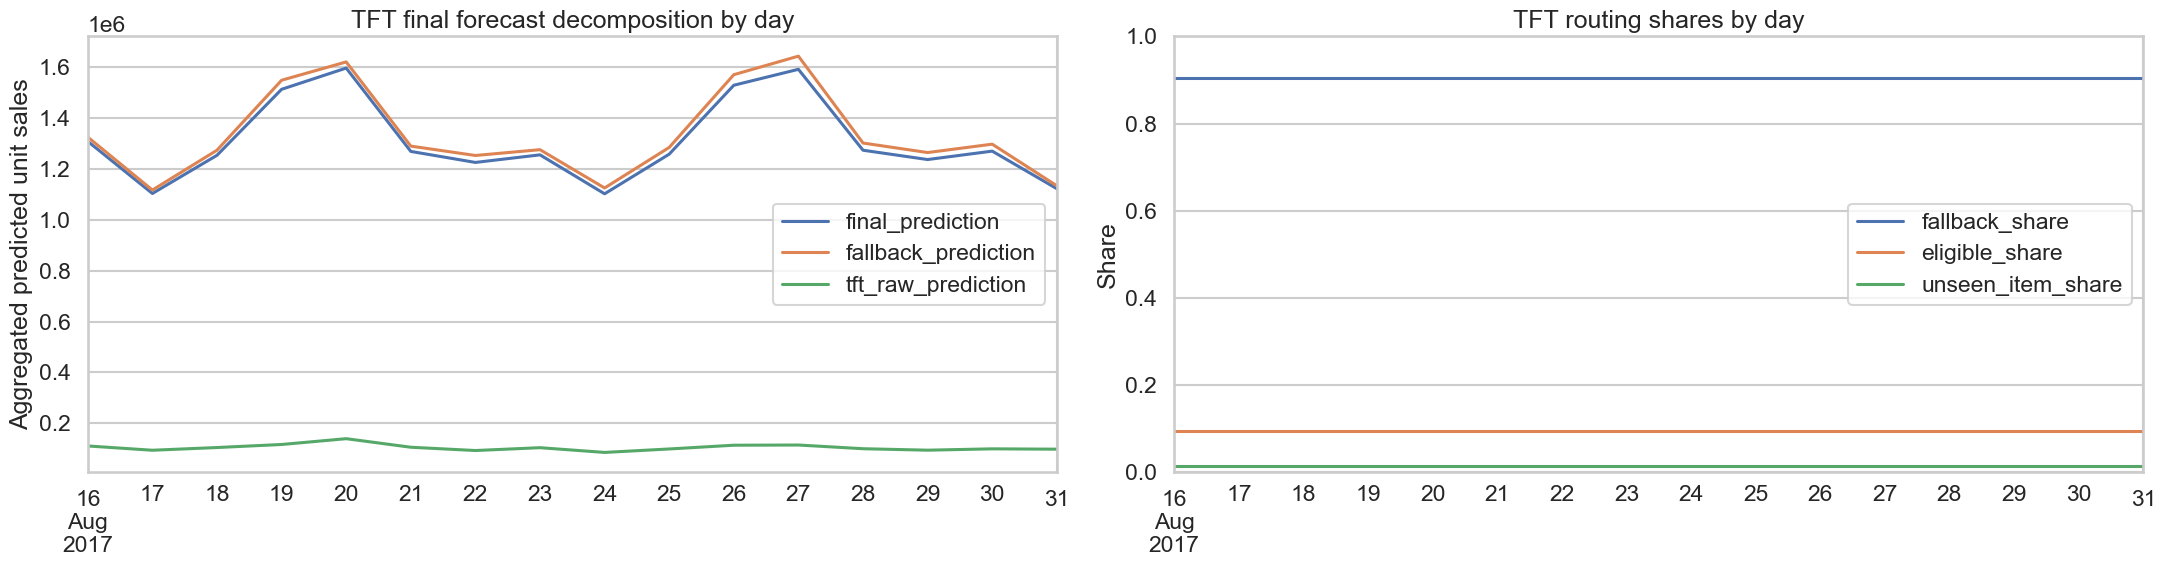

In [24]:
if tft_report_ready:
    tft_predictions = pd.read_csv(
        tft_predictions_path,
        parse_dates=["date"],
        usecols=[
            "id",
            "date",
            "final_prediction",
            "fallback_prediction",
            "tft_raw_prediction",
            "used_fallback",
            "is_tft_eligible",
            "unseen_item_flag",
        ],
    )

    tft_daily = (
        tft_predictions
        .groupby("date", as_index=False)[["final_prediction", "fallback_prediction"]]
        .sum()
        .sort_values("date", ignore_index=True)
    )

    tft_daily_tft_component = (
        tft_predictions
        .assign(tft_raw_prediction=tft_predictions["tft_raw_prediction"].fillna(0.0))
        .groupby("date", as_index=False)["tft_raw_prediction"]
        .sum()
        .sort_values("date", ignore_index=True)
    )
    tft_daily = tft_daily.merge(tft_daily_tft_component, on="date", how="left")

    tft_routing_daily = (
        tft_predictions
        .groupby("date", as_index=False)[["used_fallback", "is_tft_eligible", "unseen_item_flag"]]
        .mean()
        .rename(
            columns={
                "used_fallback": "fallback_share",
                "is_tft_eligible": "eligible_share",
                "unseen_item_flag": "unseen_item_share",
            }
        )
        .sort_values("date", ignore_index=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(22, 6))

    tft_daily.plot(
        x="date",
        y=["final_prediction", "fallback_prediction", "tft_raw_prediction"],
        ax=axes[0],
        linewidth=2.2,
    )
    axes[0].set_title("TFT final forecast decomposition by day")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Aggregated predicted unit sales")

    tft_routing_daily.plot(
        x="date",
        y=["fallback_share", "eligible_share", "unseen_item_share"],
        ax=axes[1],
        linewidth=2.2,
    )
    axes[1].set_title("TFT routing shares by day")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Share")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


In [25]:
if tft_report_ready:
    tft_submission = pd.read_csv(tft_submission_path, compression="gzip")

    consistency = pd.DataFrame(
        [
            {
                "metric": "submission_rows",
                "value": int(len(tft_submission)),
            },
            {
                "metric": "prediction_rows",
                "value": int(len(tft_predictions)),
            },
            {
                "metric": "same_row_count_submission_vs_predictions",
                "value": bool(len(tft_submission) == len(tft_predictions)),
            },
            {
                "metric": "submission_duplicate_ids",
                "value": int(tft_submission["id"].duplicated().sum()),
            },
            {
                "metric": "prediction_duplicate_ids",
                "value": int(tft_predictions["id"].duplicated().sum()),
            },
            {
                "metric": "id_set_mismatch_count",
                "value": int(len(set(tft_submission["id"]) ^ set(tft_predictions["id"]))),
            },
            {
                "metric": "mean_unit_sales_submission",
                "value": float(tft_submission["unit_sales"].mean()),
            },
            {
                "metric": "mean_final_prediction_predictions",
                "value": float(tft_predictions["final_prediction"].mean()),
            },
            {
                "metric": "fallback_share_overall",
                "value": float(tft_predictions["used_fallback"].mean()),
            },
            {
                "metric": "eligible_share_overall",
                "value": float(tft_predictions["is_tft_eligible"].mean()),
            },
        ]
    )

    display(consistency)
    display(tft_submission.head(10))


,metric,value
0,submission_rows,3370464
1,prediction_rows,3370464
2,same_row_count_submission_vs_predictions,True
3,submission_duplicate_ids,0
4,prediction_duplicate_ids,0
5,id_set_mismatch_count,0
6,mean_unit_sales_submission,6.201
7,mean_final_prediction_predictions,6.201
8,fallback_share_overall,0.905
9,eligible_share_overall,0.095


,id,unit_sales
0,125497040,1.000
1,125497041,1.888
2,125497042,3.735
3,125497043,2.320
4,125497044,3.222
5,125497045,7.760
6,125497046,11.420
7,125497047,4.123
8,125497048,2.652
9,125497049,1.444


## Выводы после EDA и baselines

- Временной ряд явно нестационарен: видны долгосрочный рост, сильная недельная сезонность и отдельные режимные сдвиги.
- Выходные заметно сильнее будней; дни 15 числа и конца месяца тоже выглядят выше среднего, что согласуется с описанием задачи.
- `transactions` хорошо сонаправлены с продажами, поэтому это сильный кандидат в baseline-признаки.
- `onpromotion` нельзя бездумно превращать в `False`: доля пропусков существенная, а сами нули продаж в train отсутствуют.
- Землетрясение 16 апреля 2016 года создаёт локальный structural break, который стоит учитывать отдельным признаком/режимом.
- В `test.csv` есть unseen items, значит для cold-start по item нужен backoff хотя бы до `family`/`class`.
- Для holidays обязательно нужно отдельно обработать `transferred`, `Bridge` и `Work Day`, иначе календарные признаки будут шумными.
- Из двух простых baseline-моделей лучше работает иерархическая схема с `weekday`/`family`/`promotion`.
- Первый `LightGBM` с табличными признаками уже заметно улучшает holdout-метрику относительно lookup-baseline.
- Более строгий rolling-origin CV показал, что окно `224` дня стабильнее и лучше `112` по среднему WRMSLE.
- После первого Kaggle прогона стало ясно, что observed-row holdout слишком оптимистичен, поэтому основной акцент сместился на pseudo-public full-panel validation.
- Текущая боевая модель - `CatBoost` на sampled recent train с aggregate priors и recent-train cache.
- Лучший вручную проверенный `CatBoost` fold сейчас заметно ближе к реальной leaderboard-логике, чем старые observed-row offline scores.
- Главные драйверы текущей модели: `si_recent28`, `siw_mean`, `siw_count_log`, `onpromotion` и соотношение recent `28/56` дней.

Что можно делать следующим шагом:
1. добить полный `CatBoost` rolling CV для `lookback_grid=(168, 224)`;
2. запустить более длинный `Optuna`, а не мини-поиск на `2` trial'ах;
3. отдельно валидировать cold-start fallback и только потом возвращать его в final blend.